# **Imports**

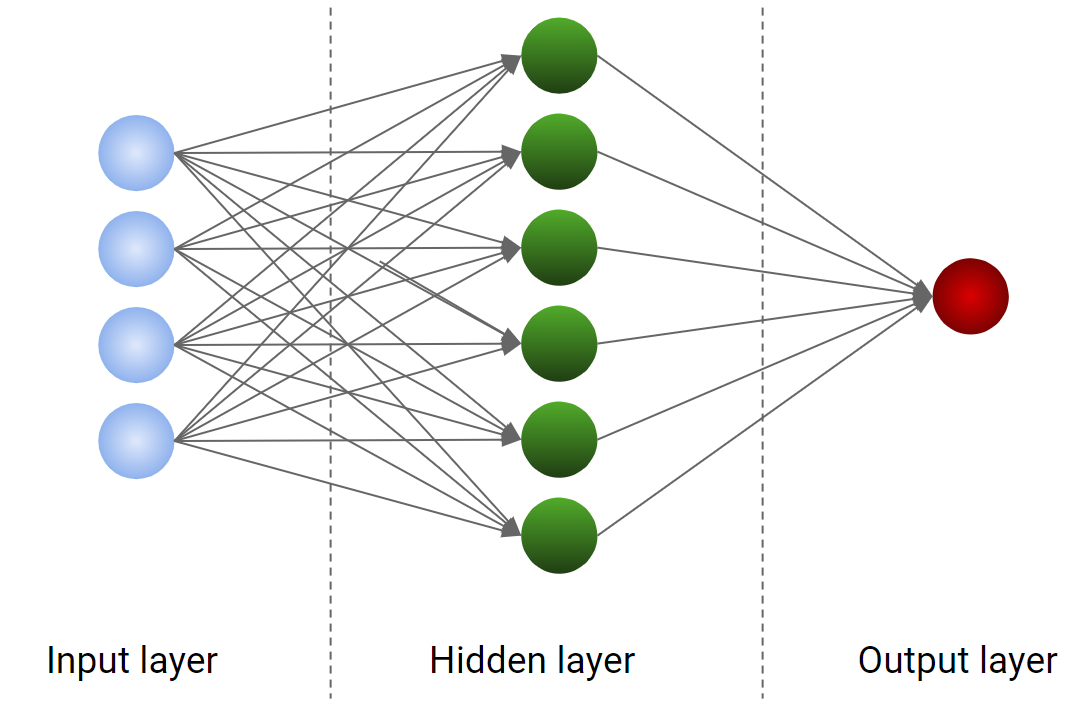

In [ ]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
import zipfile

# **Load Dataset**

In [ ]:
!cp .

!cp .

'cp' is not recognized as an internal or external command,
operable program or batch file.
'cp' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
zip_path = r"C:\Teaching_DL\datasets.zip"

extract_to = r"C:\Teaching_DL"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Teaching_DL\\datasets.zip'

In [ ]:
train_path = r"C:\Users\NB1\Downloads\dataset2\train.csv"
test_path  = r"C:\Users\NB1\Downloads\dataset2\test.csv"

In [ ]:
df = pd.read_csv(train_path)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.4817,6,4.443645,1.134293,1397,3.350120,36.77,-119.84,0.720
1,6.9133,8,5.976471,1.026471,862,2.535294,33.68,-117.80,2.741
2,1.5536,25,4.088785,1.000000,931,4.350467,36.60,-120.19,0.583
3,1.5284,31,2.740088,1.008811,597,2.629956,34.10,-118.32,2.000
4,4.0815,21,5.166667,1.002688,1130,3.037634,37.79,-121.23,1.179


## Train

In [ ]:
df_train = pd.read_csv(train_path)
x_train = df_train.drop('MedHouseVal', axis=1)
y_train = df_train['MedHouseVal']

In [ ]:
y_train

0        0.720
1        2.741
2        0.583
3        2.000
4        1.179
         ...  
16507    0.938
16508    1.031
16509    1.926
16510    1.535
16511    0.811
Name: MedHouseVal, Length: 16512, dtype: float64

## Test

In [ ]:
df_test = pd.read_csv(test_path)
x_test = df_test.drop('MedHouseVal', axis=1)
y_test = df_test['MedHouseVal']

# **Preprocessing**

## Convert to tensor

### Train

In [ ]:
torch.tensor(x_train.values , dtype=torch.float32)

tensor([[   1.4817,    6.0000,    4.4436,  ...,    3.3501,   36.7700,
         -119.8400],
        [   6.9133,    8.0000,    5.9765,  ...,    2.5353,   33.6800,
         -117.8000],
        [   1.5536,   25.0000,    4.0888,  ...,    4.3505,   36.6000,
         -120.1900],
        ...,
        [   4.4958,   19.0000,    5.8998,  ...,    2.8112,   38.9200,
         -121.2200],
        [   2.5750,   39.0000,    3.5912,  ...,    3.2937,   34.1600,
         -118.1400],
        [   2.2478,   31.0000,    5.1238,  ...,    2.9976,   40.8000,
         -124.1300]])

In [ ]:
torch.FloatTensor

torch.FloatTensor

In [ ]:
x_train = torch.FloatTensor(x_train.values)
y_train = torch.FloatTensor(y_train.values)

### Test

In [ ]:
x_test = torch.FloatTensor(x_test.values)
y_test = torch.FloatTensor(y_test.values)

In [ ]:
x_test.shape
y_train.shape

torch.Size([16512])

## Normalize

In [ ]:
x_train.mean(dim = 0)

tensor([ 3.8641e+00,  2.8625e+01,  5.4127e+00,  1.0946e+00,  1.4350e+03,
         3.0805e+00,  3.5627e+01, -1.1956e+02])

In [ ]:
mu = x_train.mean(dim = 0)
std = x_train.std(dim = 0)

In [ ]:
x_train = (x_train - mu) / std

In [ ]:
x_train.mean(dim = 0)
x_train.std(dim = 0)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [ ]:
x_test = (x_test - mu) / std

In [ ]:
x_test.mean(dim = 0)

tensor([ 0.0174,  0.0059,  0.0357,  0.0232, -0.0412, -0.0045,  0.0125, -0.0141])

# **Dataloader**

In [ ]:
train_dataset = TensorDataset(x_train, y_train)
train_dataset

In [ ]:
train_dataset.tensors

(tensor([[-1.2584, -1.7959, -0.4252,  ...,  0.0247,  0.5345, -0.1376],
         [ 1.6106, -1.6371,  0.2473,  ..., -0.0499, -0.9100,  0.8798],
         [-1.2204, -0.2877, -0.5809,  ...,  0.1162,  0.4551, -0.3122],
         ...,
         [ 0.3337, -0.7640,  0.2137,  ..., -0.0246,  1.5396, -0.8259],
         [-0.6809,  0.8236, -0.7992,  ...,  0.0195, -0.6856,  0.7102],
         [-0.8537,  0.1886, -0.1268,  ..., -0.0076,  2.4185, -2.2772]]),
 tensor([0.7200, 2.7410, 0.5830,  ..., 1.9260, 1.5350, 0.8110]))

In [ ]:
train_dataset.tensors[1]

tensor([0.7200, 2.7410, 0.5830,  ..., 1.9260, 1.5350, 0.8110])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
train_loader

In [ ]:
for i , (x_batch, y_batch) in enumerate(train_loader):
  print(i, x_batch.shape, y_batch.shape)
  break

0 torch.Size([128, 8]) torch.Size([128])


In [ ]:
len(train_loader)

129

In [ ]:
x_b, y_b = next(iter(train_loader))

In [ ]:
test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# **Define Model**

In [ ]:
num_feats = 8
out_feat = 1
h1 =64
h2 =32

model = nn.Sequential(nn.Linear(num_feats, h1),
                      nn.ReLU(),
                      nn.Linear(h1, h2),
                      nn.ReLU(),
                      nn.Linear(h2, out_feat))

In [ ]:
model

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

# **Loss & Optimizer**

In [ ]:
loss_fn = nn.MSELoss()
optimizer= optim.SGD(model.parameters(), lr=0.001)

# **Train Loooooop!**

In [ ]:
num_epochs = 400
loss_train_hist = []
loss_test_hist = []

for epoch in range(num_epochs):
  loss_train = 0
  for x_batch, y_batch in train_loader:
    yp = model(x_batch)
    loss = loss_fn(yp.squeeze(), y_batch)
    loss_train += loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  loss_test = 0
  for x_batch , y_batch in test_loader:
    yp = model(x_batch)
    loss_test += loss_fn(yp.squeeze(), y_batch)

    loss_total_trian  =  loss_train/len(train_loader)
    loss_total_test = loss_test/len(test_loader)

    loss_train_hist.append(loss_total_trian)
    loss_test_hist.append(loss_total_test)

  if epoch % 10 ==0 :
    print(f'Epoch = {epoch} : Loss Train ={loss_total_trian:.4}')
    print(f'Epoch = {epoch} : Loss Test ={loss_total_test:.4}')
    print()

Epoch = 0 : Loss Train =3.452
Epoch = 0 : Loss Test =2.18

Epoch = 10 : Loss Train =0.6023
Epoch = 10 : Loss Test =0.6064

Epoch = 20 : Loss Train =0.5348
Epoch = 20 : Loss Test =0.5392

Epoch = 30 : Loss Train =0.4951
Epoch = 30 : Loss Test =0.4979

Epoch = 40 : Loss Train =0.4716
Epoch = 40 : Loss Test =0.4728

Epoch = 50 : Loss Train =0.4557
Epoch = 50 : Loss Test =0.4559

Epoch = 60 : Loss Train =0.4439
Epoch = 60 : Loss Test =0.4439

Epoch = 70 : Loss Train =0.4347
Epoch = 70 : Loss Test =0.4349

Epoch = 80 : Loss Train =0.4271
Epoch = 80 : Loss Test =0.4271

Epoch = 90 : Loss Train =0.4206
Epoch = 90 : Loss Test =0.4207

Epoch = 100 : Loss Train =0.415
Epoch = 100 : Loss Test =0.4152

Epoch = 110 : Loss Train =0.41
Epoch = 110 : Loss Test =0.41

Epoch = 120 : Loss Train =0.4054
Epoch = 120 : Loss Test =0.4052

Epoch = 130 : Loss Train =0.4011
Epoch = 130 : Loss Test =0.4007

Epoch = 140 : Loss Train =0.3971
Epoch = 140 : Loss Test =0.3964

Epoch = 150 : Loss Train =0.3934
Epoch =

# **Learning Curve**

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(range(num_epochs), loss_train_hist, 'r-', label='Train')
ax.plot(range(num_epochs), loss_test_hist, 'b-', label='Test')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True)
ax.legend()

# **Prediction**